### Importing important Libraries

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
sns.set()
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

In [30]:
# Import the dataset
df = pd.read_csv("/content/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [31]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


(5110, 12)

# Data wrangling

In [32]:
original_df = df.copy()

In [33]:
# Checking for missing values
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


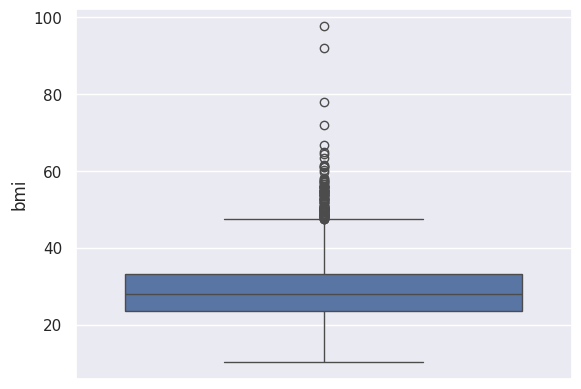

In [34]:
# Checking for outliers
sns.boxplot(y = df["bmi"], data = df)
plt.show()

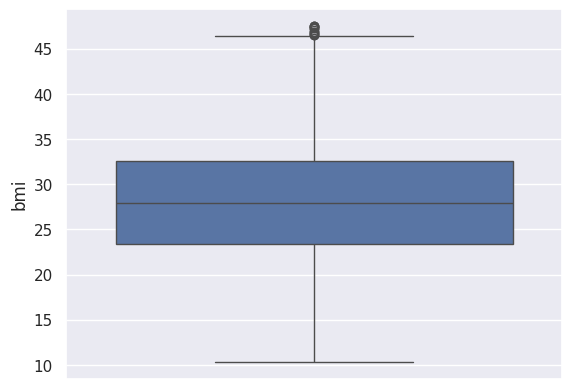

In [35]:
# Removing outliers
IQR = df["bmi"].quantile(0.75) - df["bmi"].quantile(0.25)
lower_bound = df["bmi"].quantile(0.25) - (1.5 * IQR)
upper_bound = df["bmi"].quantile(0.75) + (1.5 * IQR)
df = df[(df["bmi"] >= lower_bound) & (df["bmi"] <= upper_bound)]
sns.boxplot(y = df["bmi"], data = df)
plt.show()


In [36]:
# filling the missing values with median
df["bmi"].fillna(df["bmi"].median(), inplace = True)
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


# Exploratory Data Analysis

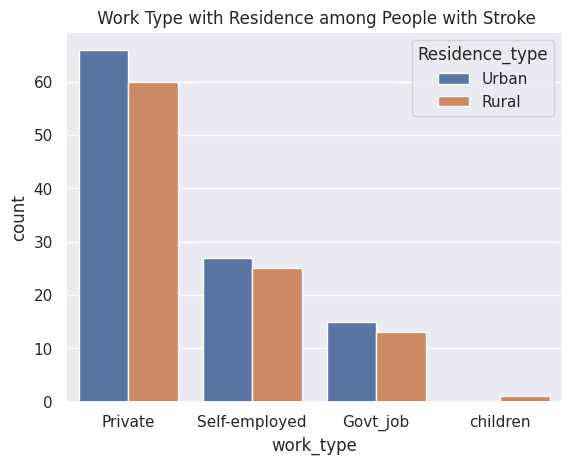

In [37]:
# Work Type with Residence among People with Stroke
people_with_stroke = df[df["stroke"] == 1]
sns.countplot(x = people_with_stroke["work_type"], data = people_with_stroke, hue="Residence_type")
plt.title(" Work Type with Residence among People with Stroke")
plt.show()

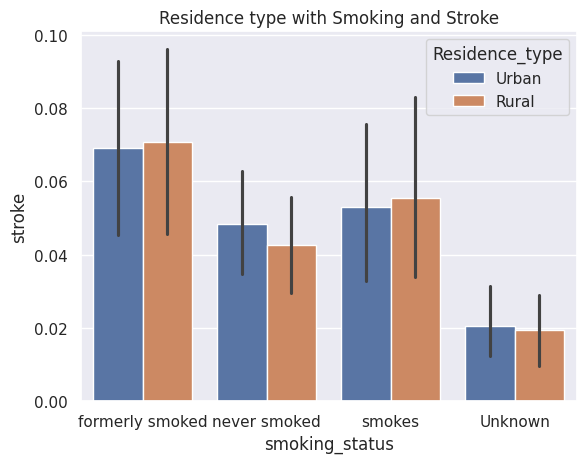

In [38]:
# realtionship between married status, smoking and stroke
sns.barplot(y= "stroke", x= "smoking_status", hue="Residence_type", data = df)
plt.title("Residence type with Smoking and Stroke")
plt.show()

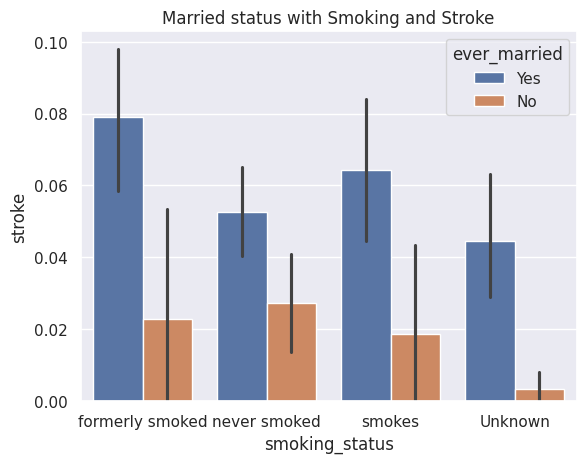

In [39]:
# realtionship between married status, smoking and stroke
sns.barplot(y= "stroke", x= "smoking_status", hue="ever_married", data = df)
plt.title("Married status with Smoking and Stroke")
plt.show()

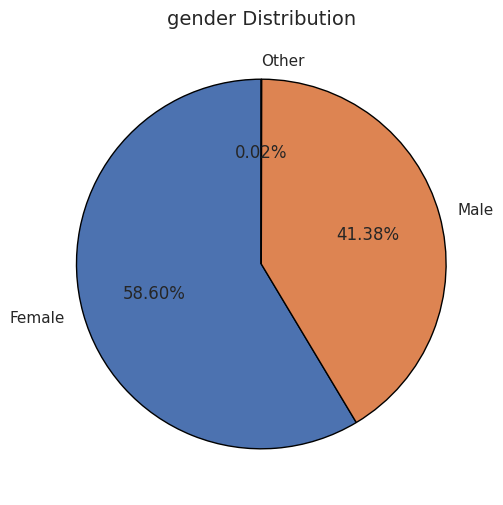

In [40]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts,
    labels=gender_counts.index,
    autopct='%1.2f%%',   # Show percentages
    startangle=90,       # Rotate start
    wedgeprops={'edgecolor': 'black'}  # Add border
)

# Add a title
plt.title('gender Distribution', fontsize=14)
plt.show()

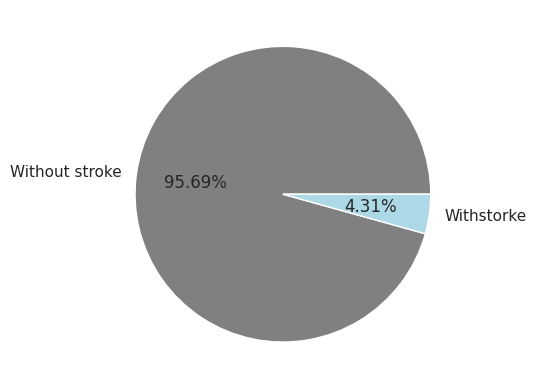

In [41]:
#with stroke vs non stroke
w_stroke_non_stroke = df["stroke"].value_counts()
plt.pie(w_stroke_non_stroke, labels =["Without stroke", "Withstorke"], autopct = "%1.2f%%", colors=["grey", "lightblue"]) # autopct to show percentage
plt.show()

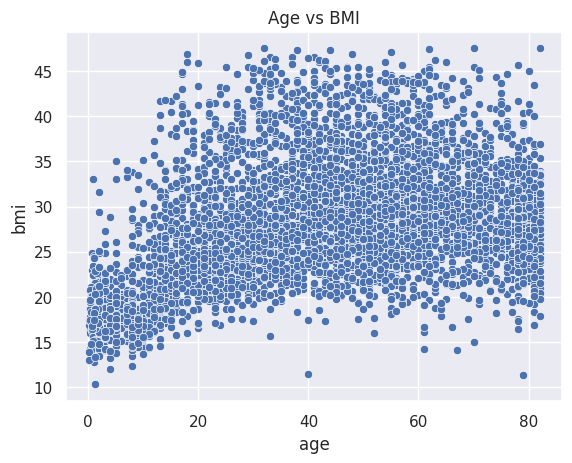

In [42]:
# Age vs BMI
sns.scatterplot(x = "age", y = "bmi", data = df)
plt.title("Age vs BMI")
plt.show()

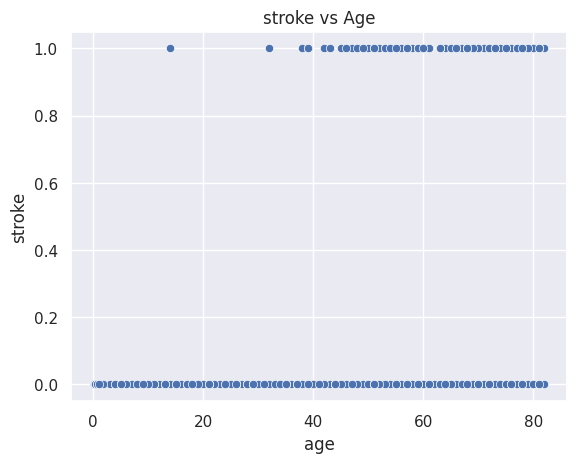

In [43]:
# relationship between age and stroke
sns.scatterplot(x="age", y="stroke", data=df)
plt.title("stroke vs Age")
plt.show()

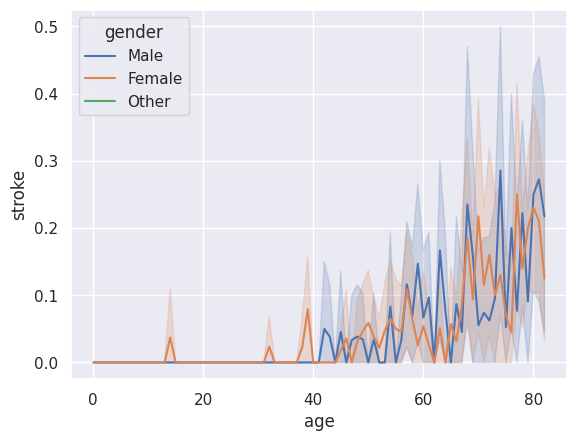

In [44]:
sns.lineplot(x= "age", y= "stroke", data = df, hue="gender")
plt.show()

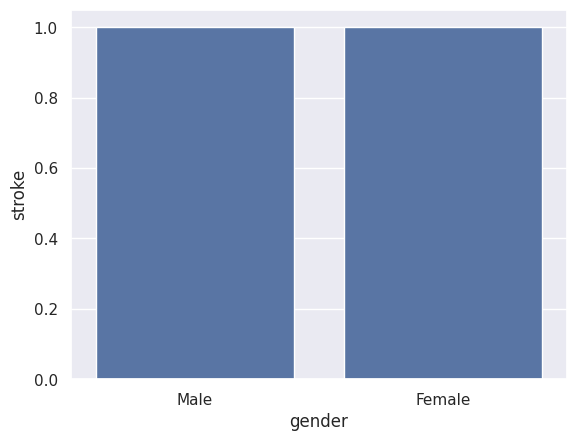

In [45]:
# which gender is more prone to stroke
sns.barplot(x="gender", y="stroke", data=people_with_stroke)
plt.show()

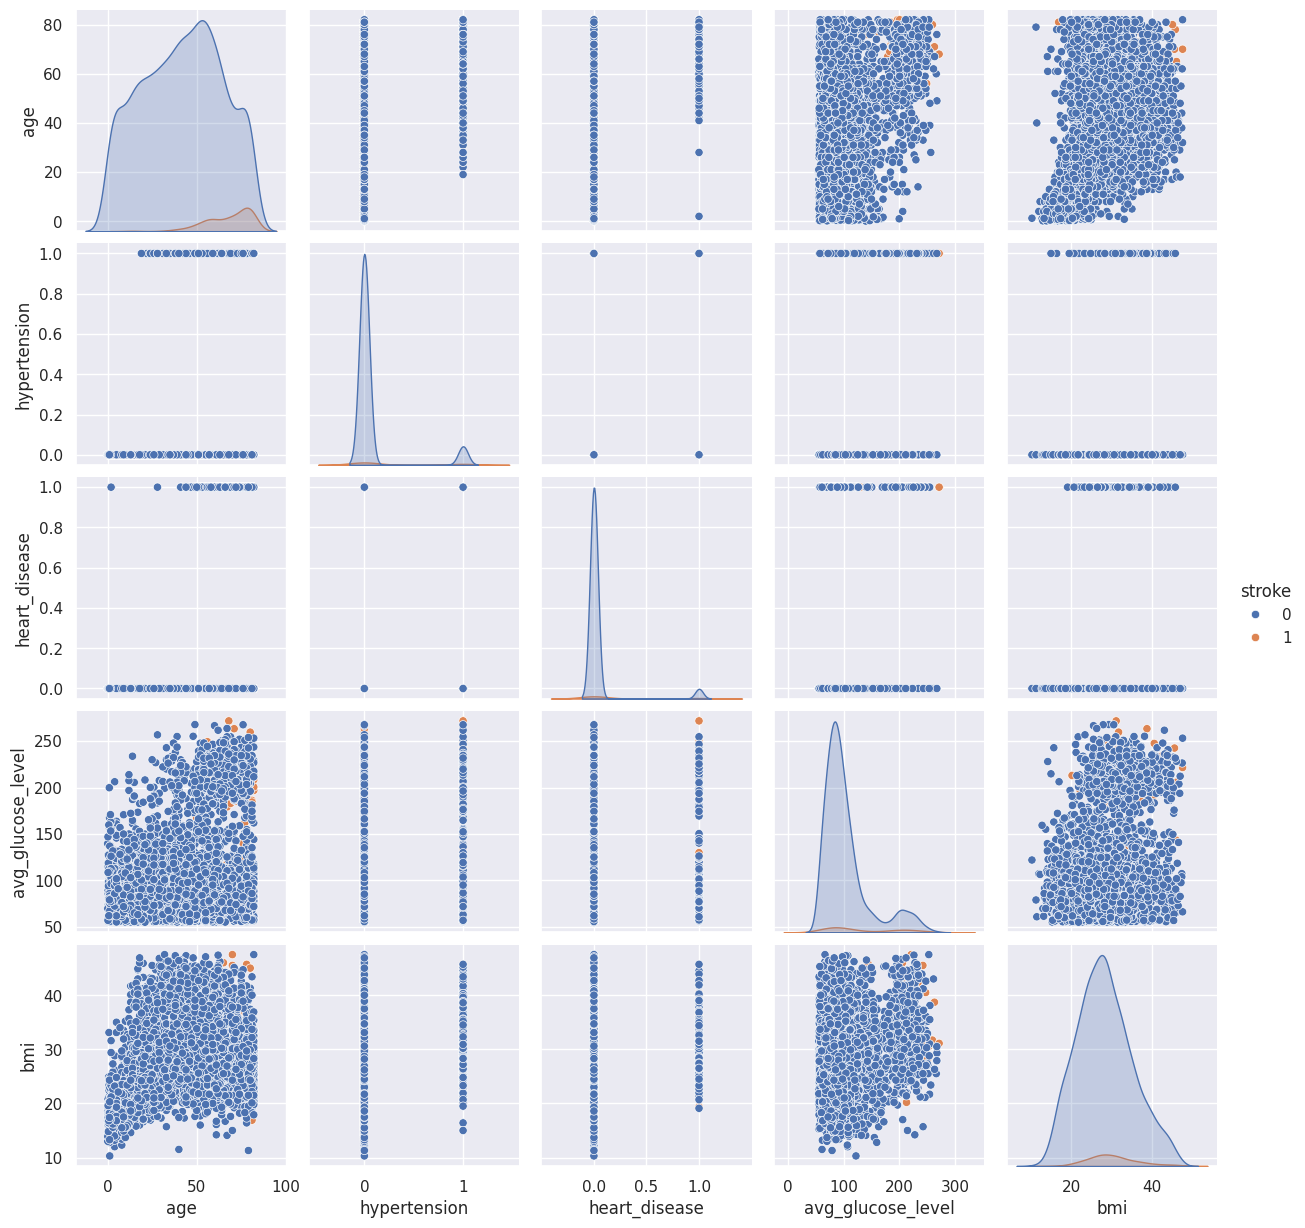

In [46]:
## Pairpolot
sns.pairplot(data= df.drop("id", axis =1), hue = "stroke")
plt.show()

In [47]:
# does storke has any correlation with average glucose level
df["stroke"].corr(df["avg_glucose_level"])

np.float64(0.13834513584876929)

In [48]:
# does storke has any correlation with average glucose level
df["stroke"].corr(df["avg_glucose_level"])

np.float64(0.13834513584876929)

In [50]:
numerical_cols = df.select_dtypes(include= ["int64", "float64"]).columns.tolist()
numerical_cols.remove("id")
numerical_cols

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

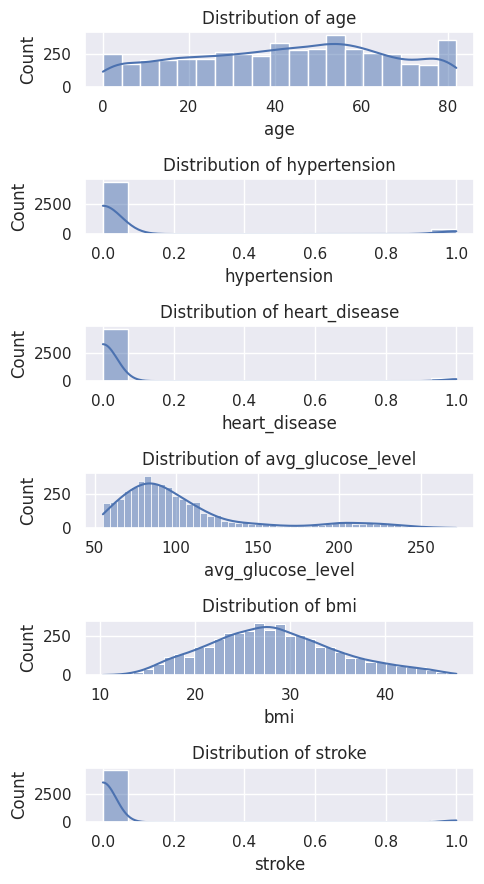

In [51]:
#Distributiion of numerical columns
fig, axes = plt.subplots(6,1, figsize=(5,9))
for col, ax in zip(numerical_cols, axes):
    sns.histplot(x= df[col], kde = True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()

# Feature Encoding

In [52]:
# Droping stroke and id columns
X = df.drop(columns=["stroke", "id"])

# Label Encoding
le = LabelEncoder()
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

y = df["stroke"]


In [53]:
# Balanced Class Distribution
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X, y)

In [54]:
# Split the data in traing and tesing set
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, random_state=42, test_size=0.2)

# Create a decision tree and fit it to the training data
DecisionTree= DecisionTreeClassifier()
DecisionTree.fit(X_train, y_train)

DecisionTreeClassifier()

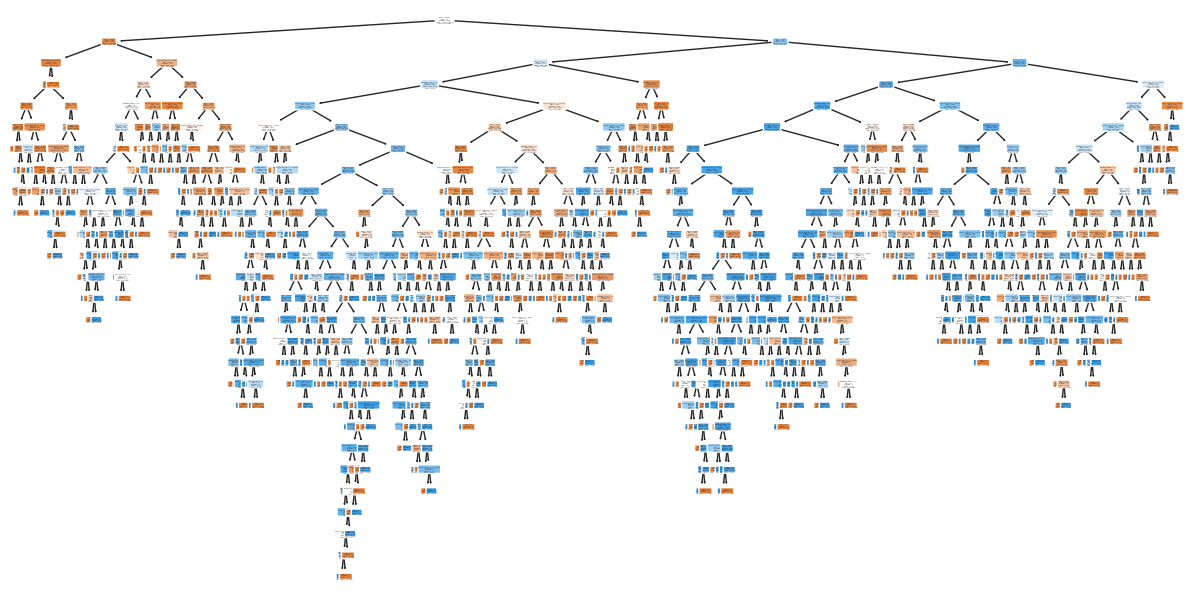

In [55]:
from sklearn.tree import plot_tree
# Plot the decision tree
plt.figure(figsize=(15, 7.5))
plot_tree(DecisionTree, filled=True, feature_names=X.columns, rounded=True, class_names=["No Stroke", "Stroke"])
plt.show()

In [56]:
# Model Accuracy before pruning
accuracy_before_pruning = DecisionTree.score(X_test, y_test)
print(f"Accuracy before pruning: {accuracy_before_pruning: }")

Accuracy before pruning:  0.9080021774632553


In [57]:
# Classification Report
y_pred = DecisionTree.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       912
           1       0.89      0.93      0.91       925

    accuracy                           0.91      1837
   macro avg       0.91      0.91      0.91      1837
weighted avg       0.91      0.91      0.91      1837



<Axes: >

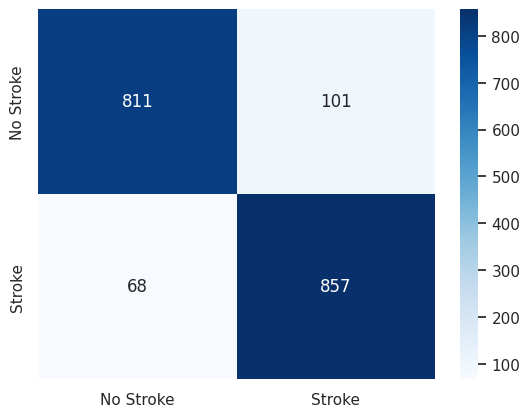

In [58]:
# Plot confusion matrix
y_pred = DecisionTree.predict(X_test)
Confusion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(Confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])

# Post pruning decision tree with cost complexity pruning

In [59]:
path = DecisionTree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [60]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf_temp = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf_temp.fit(X_train, y_train)
    clfs.append(clf_temp)
print("Number of nodes in the last tree is: {} with ccp_alpha {}".format(clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha 0.15531250518412354


# Accuracy vs alph for training and testing sets

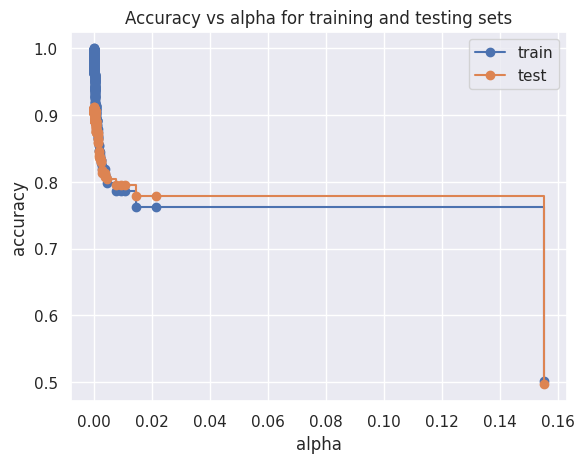

In [61]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", drawstyle="steps-post", label="train")
ax.plot(ccp_alphas, test_scores, marker="o", drawstyle="steps-post", label="test")
ax.legend()
plt.show()

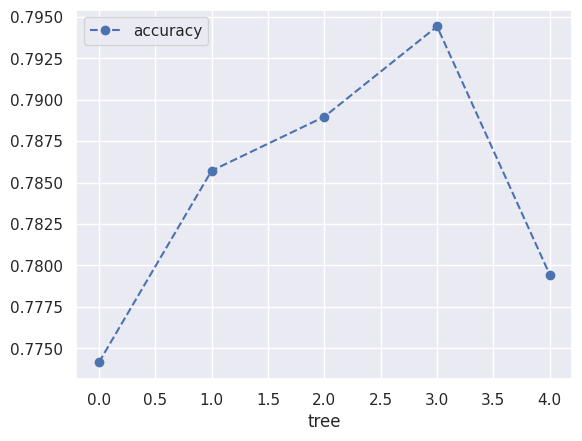

In [62]:
model = DecisionTreeClassifier(random_state=0, ccp_alpha=0.01)

scores = cross_val_score(model, X_train, y_train, cv=5)
df = pd.DataFrame({"tree": range(5), "accuracy": scores})

df.plot(x="tree", y="accuracy", marker="o", linestyle="--")
plt.show()

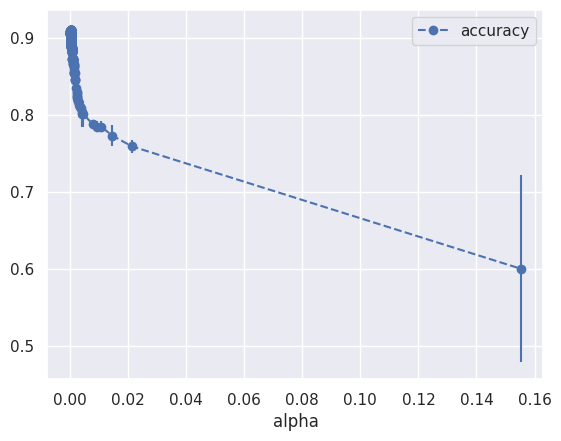

In [63]:
alpha_loop_values =[]

for ccp_alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    alpha_loop_values.append((ccp_alpha, np.mean(scores), np.std(scores)))

alpha_results = pd.DataFrame(alpha_loop_values, columns=["alpha", "accuracy", "std"])
alpha_results.plot(x="alpha", y="accuracy", yerr="std", marker="o", linestyle="--")
plt.show()

In [64]:
best_alpha_row = alpha_results.loc[(alpha_results['alpha'] > 0.01) & (alpha_results['alpha'] < 0.02)]
best_alpha_row

,alpha,accuracy,std
308,0.010824,0.784539,0.007107
309,0.014542,0.773239,0.013503


In [65]:
ideal_ccp_alpha = best_alpha_row['alpha'].iloc[1]
ideal_ccp_alpha

np.float64(0.014541690353381376)

In [66]:
model_pruning = DecisionTreeClassifier(random_state=0, ccp_alpha=ideal_ccp_alpha)
model_pruning = model_pruning.fit(X_train, y_train)

In [67]:
# Classification report
# Classification Report
prediction = DecisionTree.predict(X_test)
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       912
           1       0.89      0.93      0.91       925

    accuracy                           0.91      1837
   macro avg       0.91      0.91      0.91      1837
weighted avg       0.91      0.91      0.91      1837



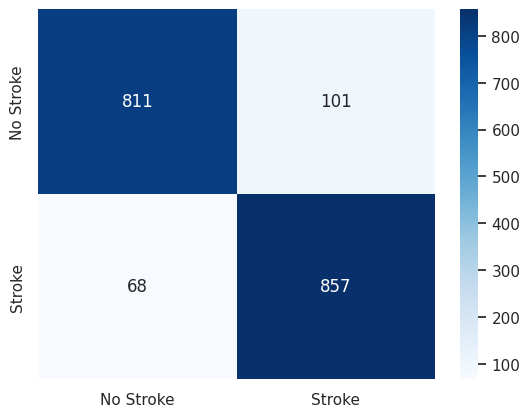

In [68]:
# Plot confusion matrix
Confusion_matrix = confusion_matrix(y_test, prediction)
sns.heatmap(Confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])
plt.show()

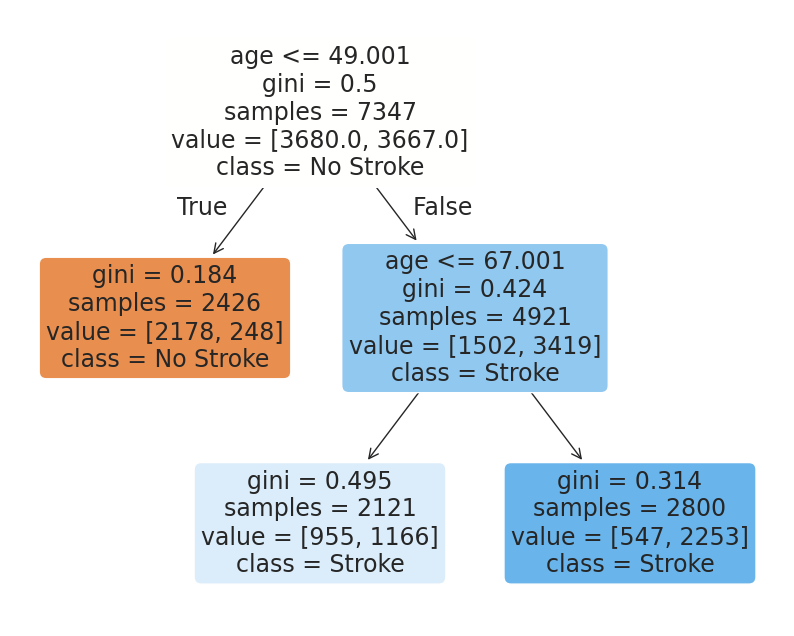

In [69]:
plt.figure(figsize=(10, 8))
plot_tree(model_pruning, filled=True, feature_names=X.columns, rounded=True, class_names=["No Stroke", "Stroke"])
plt.show()
